In [7]:
import sklearn
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd
import os


In [8]:

def preprocess_fish_image(image_path):
    
    # 1. Chargement et conversion en niveaux de gris
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 2. Seuillage inverse pour détecter les traits sombres du dessin
    _, binary = cv2.threshold(gray, 220, 255, cv2.THRESH_BINARY_INV)
    
    # 3. Fermeture morphologique pour lier le contour extérieur
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    
    # 4. Contour du poisson (en ignorant la bordure extérieure rectangulaire)
    contours, _ = cv2.findContours(closed, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    h, w = gray.shape
    valid_contours = [c for c in contours if cv2.boundingRect(c)[2] < w - 10 and cv2.contourArea(c) > 500]
    
    # 5. Création du masque binaire solide
    mask = np.zeros_like(gray)
    cv2.drawContours(mask, valid_contours, -1, 255, -1)
    
    # 6. Conservation des niveaux de gris à l'intérieur + fond blanc uniforme
    extracted = gray.copy()
    extracted[mask == 0] = 255
    
    # 7. Recadrage au plus près de la silhouette (Bounding Box)
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x, y, bw, bh = cv2.boundingRect(np.vstack(cnts))
    cropped = extracted[y:y+bh, x:x+bw]
    
    return cropped

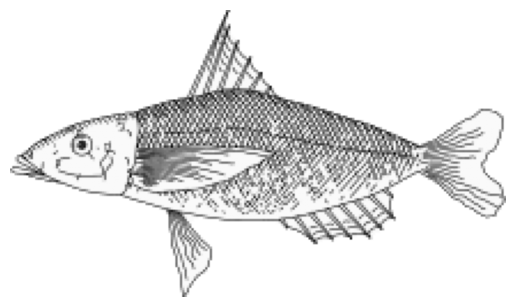

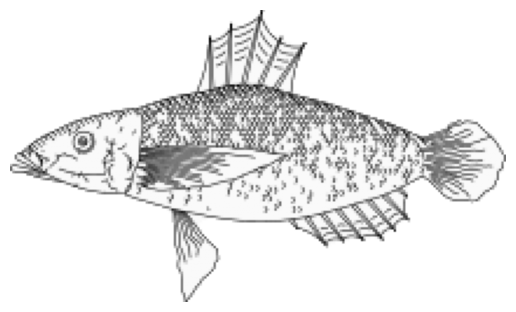

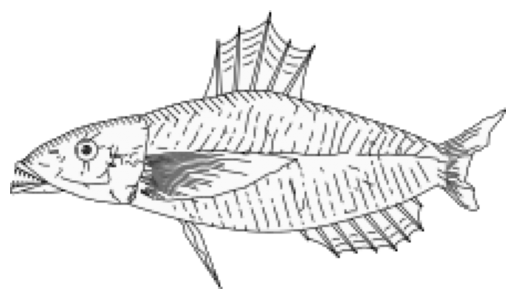

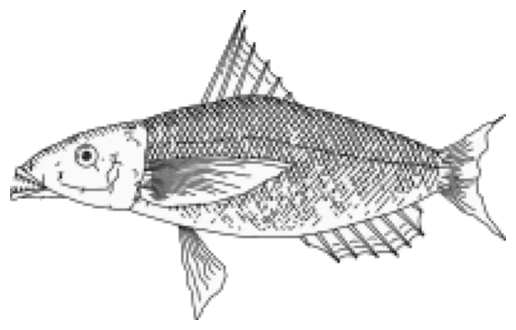

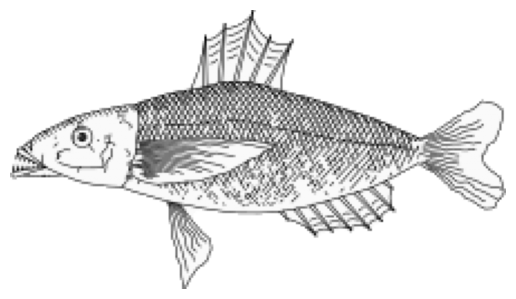

In [10]:
for i in range(1, 6):
    image_path = f"lot0/fish_0000{i}.png"
    processed_image = preprocess_fish_image(image_path)
    plt.imshow(processed_image, cmap='gray')
    plt.axis('off')
    plt.show()



In [19]:
input_folder = "./lot0"
data = "./lot0/labels.csv"

labels_df = pd.read_csv(data).set_index("filename")
label_columns = labels_df.columns.tolist()

images = []
labels = []
filenames = []

for filename in sorted(os.listdir(input_folder)):
    if not filename.endswith(".png"):
        continue

    if filename not in labels_df.index:
        print(f"No label for {filename}, skipped")
        continue

    image_path = os.path.join(input_folder, filename)
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f"Could not read {filename}, skipped")
        continue

    images.append(image)
    labels.append(labels_df.loc[filename].values)
    filenames.append(filename)

X_images = np.array(images)
y_labels = np.array(labels)

print(X_images.shape, y_labels.shape)
print(filenames[0], dict(zip(label_columns, y[0])))

(100, 160, 260) (100, 7)
fish_00000.png {'scale_type': np.int64(0), 'dorsal_type': np.int64(1), 'wing_type': np.int64(0), 'pelvic_type': np.int64(0), 'tail_type': np.int64(5), 'eye_type': np.int64(0), 'has_teeth': np.int64(1)}


In [59]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split

SIZES = [4, 2, 2, 2, 6, 2, 2]
NAMES = ["scale", "dorsal", "wing", "pelvic", "tail", "eye", "teeth"]

X_t = torch.tensor(X_images, dtype=torch.float)
y_t = torch.tensor(y_labels, dtype=torch.long)

X_t = X_t.unsqueeze(1)
X_t = X_t / 255.0 

dataset = TensorDataset(X_t, y_t)
train_set, test_set = random_split(dataset, [80, 20], generator=torch.Generator().manual_seed(69))

train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=16, shuffle=False)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1), nn.ReLU(), nn.MaxPool2d(2), 
            nn.Conv2d(16,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2), 
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2), 
            nn.AdaptiveAvgPool2d((20, 32))
        )
        self.fc = nn.Sequential(
            nn.Linear(64*20*32,256), nn.ReLU(),
            nn.Linear(256,64), nn.ReLU(),
            nn.Linear(64, sum(SIZES))
        )

    def forward(self,x):
        x = self.conv(x)
        return self.fc(x.view(x.size(0),-1))

model = CNN()

def split(out):
    return torch.split(out, SIZES, dim=1)

opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(60):
    model.train()
    for x,y in train_loader:
        opt.zero_grad()
        groups = split(model(x))
        loss = 0                                         
        for i in range(7):                                
            loss = loss + loss_fn(groups[i], y[:, i])     
        loss.backward()
        opt.step()


def accuracy(loader):
    model.eval()
    correct = [0] * 7
    total = 0
    with torch.no_grad():
        for x, y in loader:
            groups = split(model(x))
            for i in range(7):
                pred = groups[i].argmax(1)
                correct[i] += (pred == y[:, i]).sum().item()
            total += y.size(0)
    return [100 * c / total for c in correct]

train_acc = accuracy(train_loader)
test_acc = accuracy(test_loader)
for i in range(7):
    print(f"{NAMES[i]:>7}: train {train_acc[i]:5.1f} %   test {test_acc[i]:5.1f} %")
    
print(f"Global accuracy: train {sum(train_acc)/7:.1f} %   test {sum(test_acc)/7:.1f} %")

  scale: train 100.0 %   test 100.0 %
 dorsal: train 100.0 %   test 100.0 %
   wing: train 100.0 %   test  85.0 %
 pelvic: train 100.0 %   test 100.0 %
   tail: train 100.0 %   test  85.0 %
    eye: train  86.2 %   test  60.0 %
  teeth: train 100.0 %   test  80.0 %
Global accuracy: train 98.0 %   test 87.1 %
